# Lập trình Rule-based AI
Áp dụng phương pháp nhìn trước nước đi (Look-Ahead Search) 1 bước, 2 bước và 3 bước cho trò chơi Tic Tac Toe theo kiến trúc của AlphaGo Simplified.

## Nạp môi trường và framework

In [1]:
import numpy as np
from copy import deepcopy
import random
import time

# Nạp môi trường cờ ca-rô TicTacToe (bản ttt_simple_env thuần logic, tốc độ cao không GUI)
from utils.ttt_simple_env import ttt

# Định nghĩa người chơi đánh ngẫu nhiên
def ttt_random(env):
    return env.sample()

# Hàm mô phỏng 1 ván đấu hoàn chỉnh giữa 2 đấu thủ (player1 đi trước, player2 đi sau)
def one_ttt_game(player1, player2):
    env = ttt()
    env.reset()     
    while True:    
        # Lượt player1 (quân X)
        action = player1(env)  
        state, reward, done, _ = env.step(action)
        if done:
            break
            
        # Lượt player2 (quân O)
        action = player2(env)  
        state, reward, done, _ = env.step(action)
        if done:
            break            
    return reward  # 1: player1 thắng, -1: player2 thắng, 0: hòa


## Xem trước 1 bước trong trò chơi

In [2]:
def ttt_think1(env):
    """
    AI xem trước 1 bước:
    - Duyệt qua từng nước đi hợp lệ hiện tại.
    - Dùng deepcopy để giả định nước đi.
    - Nếu nước đi giúp thắng ngay (done và reward = 1 hoặc -1), chọn ngay nước đó.
    - Nếu không có nước nào thắng ngay, chọn ngẫu nhiên.
    """
    for m in env.validinputs:
        env_copy = deepcopy(env)
        state, reward, done, _ = env_copy.step(m)
        if done and abs(reward) == 1:
            return m
    return env.sample()

# Thử nghiệm đánh giá hiệu quả: ttt_think1 đấu với ttt_random (1000 ván)
print("Đang chạy thử nghiệm ttt_think1 vs ttt_random (1000 ván)...\n")
results_think1 = []
for i in range(1000):
    if i % 2 == 0:
        # AI đi trước (X)
        r = one_ttt_game(ttt_think1, ttt_random)
        results_think1.append(r)
    else:
        # AI đi sau (O) - đảo dấu để 1 luôn đại diện cho AI thắng
        r = one_ttt_game(ttt_random, ttt_think1)
        results_think1.append(-r)

wins = results_think1.count(1)
losses = results_think1.count(-1)
ties = results_think1.count(0)
print(f"Kết quả sau 1000 ván (think1 vs random):")
print(f" - AI thắng : {wins} ({wins/10:.1f}%)")
print(f" - AI thua  : {losses} ({losses/10:.1f}%)")
print(f" - Hòa      : {ties} ({ties/10:.1f}%)")


## Xem trước 2 bước trong trò chơi

In [3]:
def ttt_think2(env):
    """
    AI xem trước 2 bước:
    1. Kiểm tra nếu có nước thắng ngay (1 bước) -> đánh ngay.
    2. Nếu không, dự đoán 2 bước tiếp theo (m1 của ta, m2 của đối thủ):
       Nếu đối thủ thắng ở lượt m2 -> chặn ngay hiểm họa bằng cách đánh vào m2.
    3. Nếu không có hiểm họa -> đi ngẫu nhiên.
    """
    # 1. Tìm nước thắng ngay cho bản thân
    for m in env.validinputs:
        env_copy = deepcopy(env)
        state, reward, done, _ = env_copy.step(m)
        if done and abs(reward) == 1:
            return m

    # 2. Dự đoán 2 bước để chặn đối thủ
    for m1 in env.validinputs:
        for m2 in env.validinputs:
            if m1 != m2:
                env_copy = deepcopy(env)
                s, r, done, _ = env_copy.step(m1)
                s, r, done, _ = env_copy.step(m2)
                # Nếu đối thủ thắng ở bước m2 -> phải chặn ngay ô m2
                if done and r != 0:
                    return m2

    # 3. Nếu không có đe dọa, chọn ngẫu nhiên
    return env.sample()

# Thử nghiệm đánh giá hiệu quả: ttt_think2 đấu với ttt_think1 (1000 ván)
print("Đang chạy thử nghiệm ttt_think2 vs ttt_think1 (1000 ván)...\n")
results_think2 = []
for i in range(1000):
    if i % 2 == 0:
        r = one_ttt_game(ttt_think2, ttt_think1)
        results_think2.append(r)
    else:
        r = one_ttt_game(ttt_think1, ttt_think2)
        results_think2.append(-r)

wins = results_think2.count(1)
losses = results_think2.count(-1)
ties = results_think2.count(0)
print(f"Kết quả sau 1000 ván (think2 vs think1):")
print(f" - think2 thắng : {wins} ({wins/10:.1f}%)")
print(f" - think2 thua  : {losses} ({losses/10:.1f}%)")
print(f" - Hòa          : {ties} ({ties/10:.1f}%)")


## Xem trước 3 bước trong trò chơi

In [4]:
def ttt_think3(env):
    """
    AI xem trước 3 bước:
    1. Tìm nước thắng ngay (1 bước).
    2. Chặn nước thắng của đối thủ (2 bước).
    3. Xem trước 3 bước: Ta (m1) -> Đối thủ (m2) -> Ta (m3).
       Nếu m3 thắng, lưu lại nước m1. Chọn nước m1 tạo ra nhiều kịch bản thắng nhất
       (thế công đôi / double attack - đối thủ chỉ có thể đỡ được 1 đường).
    4. Nếu không có, đi ngẫu nhiên.
    """
    # 1. Tìm nước thắng ngay
    for m in env.validinputs:
        env_copy = deepcopy(env)
        state, reward, done, _ = env_copy.step(m)
        if done and abs(reward) == 1:
            return m

    # 2. Chặn đối thủ thắng ở bước 2
    for m1 in env.validinputs:
        for m2 in env.validinputs:
            if m1 != m2:
                env_copy = deepcopy(env)
                s, r, done, _ = env_copy.step(m1)
                s, r, done, _ = env_copy.step(m2)
                if done and r != 0:
                    return m2

    # 3. Xem trước 3 bước để tìm nước tạo ra thế công đôi (Double Attack)
    w3 = []
    for m1 in env.validinputs:
        for m2 in env.validinputs:
            for m3 in env.validinputs:
                if m1 != m2 and m1 != m3 and m2 != m3:
                    env_copy = deepcopy(env)
                    s, r, done, _ = env_copy.step(m1)
                    s, r, done, _ = env_copy.step(m2)
                    s, r, done, _ = env_copy.step(m3)
                    if done and r != 0:
                        w3.append(m1)

    # Chọn nước m1 có số lần dẫn đến chiến thắng nhiều nhất
    if len(w3) > 0:
        return max(w3, key=w3.count)

    # 4. Nếu không có kịch bản nào, đi ngẫu nhiên
    return env.sample()

# Thử nghiệm đánh giá hiệu quả: ttt_think3 đấu với ttt_think2 (1000 ván)
print("Đang chạy thử nghiệm ttt_think3 vs ttt_think2 (1000 ván)...\n")
results_think3 = []
for i in range(1000):
    if i % 2 == 0:
        r = one_ttt_game(ttt_think3, ttt_think2)
        results_think3.append(r)
    else:
        r = one_ttt_game(ttt_think2, ttt_think3)
        results_think3.append(-r)

wins = results_think3.count(1)
losses = results_think3.count(-1)
ties = results_think3.count(0)
print(f"Kết quả sau 1000 ván (think3 vs think2):")
print(f" - think3 thắng : {wins} ({wins/10:.1f}%)")
print(f" - think3 thua  : {losses} ({losses/10:.1f}%)")
print(f" - Hòa          : {ties} ({ties/10:.1f}%)")


## Rule-based AI dựa vào "Human Problem Solving" của Newell & Simon (1972)

**Bản chất:** Rule-based AI không tự "học" từ dữ liệu mà thực thi hệ luật chuyên gia do con người thiết lập sẵn. Năm 1972, hai nhà khoa học tiên phong về AI là **Allen Newell** và **Herbert Simon** đã chứng minh hệ thống **8 quy tắc ưu tiên tuần tự** giúp người chơi **BẤT BẠI 100% (Thua = 0%)** trong Tic Tac Toe:

1. **Win (Thắng ngay):** Nếu có 2 quân thẳng hàng, đi ô thứ 3 để thắng ngay.
2. **Block (Chặn ngay):** Nếu đối thủ có 2 quân thẳng hàng, đi ô thứ 3 để chặn đối thủ.
3. **Fork (Tạo thế song sát):** Đánh vào ô tạo ra 2 đường thắng tiềm năng cùng lúc (buộc đối thủ chỉ đỡ được 1 đường).
4. **Block Fork (Phá thế song sát đối thủ):** Tạo phản công buộc đối thủ phải đỡ (nước đỡ không tạo Fork), hoặc chặn trực tiếp ô Fork của đối thủ.
5. **Center (Chiếm tâm):** Đánh vào ô chính giữa (ô số 5).
6. **Opposite Corner (Góc đối diện):** Nếu đối thủ chiếm một góc, đánh vào góc đối diện trên đường chéo.
7. **Empty Corner (Chiếm góc trống):** Đánh vào bất kỳ góc nào còn trống (1, 3, 7, 9).
8. **Empty Side (Chiếm cạnh trống):** Đánh vào ô cạnh giữa còn trống (2, 4, 6, 8).

In [5]:
# 8 đường thắng chuẩn trong Tic Tac Toe (theo tọa độ bàn cờ 1-9)
LINES = [
    (1, 2, 3), (4, 5, 6), (7, 8, 9),  # 3 hàng ngang
    (1, 4, 7), (2, 5, 8), (3, 6, 9),  # 3 hàng dọc
    (1, 5, 9), (3, 5, 7)              # 2 đường chéo
]

def count_threats(state, piece):
    """Đếm số đường có 2 quân của 'piece' và 1 ô trống (mối đe dọa thắng)"""
    threats = 0
    for a, b, c in LINES:
        line = [state[a - 1], state[b - 1], state[c - 1]]
        if line.count(piece) == 2 and line.count(0) == 1:
            threats += 1
    return threats

def ttt_newell_simon(env):
    """
    Rule-based AI áp dụng triệt để 8 luật ưu tiên của Newell & Simon (1972)
    Đảm bảo 100% không thua (chỉ Thắng hoặc Hòa).
    """
    my_piece = 1 if env.turn == 'X' else -1
    opp_piece = -my_piece
    valid = env.validinputs

    # 1. RULE 1: WIN (Nếu có cơ hội thắng ngay trong lượt này)
    for m in valid:
        tmp = env.state.copy()
        tmp[m - 1] = my_piece
        for a, b, c in LINES:
            if tmp[a - 1] == tmp[b - 1] == tmp[c - 1] == my_piece:
                return m

    # 2. RULE 2: BLOCK (Nếu đối thủ có thể thắng ở lượt tới -> chặn ngay)
    for m in valid:
        tmp = env.state.copy()
        tmp[m - 1] = opp_piece
        for a, b, c in LINES:
            if tmp[a - 1] == tmp[b - 1] == tmp[c - 1] == opp_piece:
                return m

    # 3. RULE 3: FORK (Tạo thế song sát - tạo ra >= 2 đường thắng tiềm năng)
    for m in valid:
        tmp = env.state.copy()
        tmp[m - 1] = my_piece
        if count_threats(tmp, my_piece) >= 2:
            return m

    # 4. RULE 4: BLOCK FORK (Hóa giải / Phá thế song sát của đối thủ)
    opp_fork_cells = []
    for m in valid:
        tmp = env.state.copy()
        tmp[m - 1] = opp_piece
        if count_threats(tmp, opp_piece) >= 2:
            opp_fork_cells.append(m)

    if opp_fork_cells:
        # Cách 4A: Phản công ép đối thủ phải đỡ, miễn là ô đỡ không nằm trong opp_fork_cells
        forced_move = None
        for m in valid:
            tmp = env.state.copy()
            tmp[m - 1] = my_piece
            for a, b, c in LINES:
                line_cells = [a, b, c]
                line_vals = [tmp[x - 1] for x in line_cells]
                if line_vals.count(my_piece) == 2 and line_vals.count(0) == 1:
                    defense_cell = line_cells[line_vals.index(0)]
                    if defense_cell not in opp_fork_cells:
                        forced_move = m
                        break
            if forced_move:
                break
        if forced_move:
            return forced_move

        # Cách 4B: Nếu không thể phản công an toàn -> chiếm trực tiếp ô Fork của đối thủ
        return opp_fork_cells[0]

    # 5. RULE 5: CENTER (Chiếm ô trung tâm 5)
    if 5 in valid:
        return 5

    # 6. RULE 6: OPPOSITE CORNER (Chiếm góc đối diện góc đối thủ đã chiếm)
    opp_corner_pairs = [(1, 9), (9, 1), (3, 7), (7, 3)]
    for opp_c, my_c in opp_corner_pairs:
        if env.state[opp_c - 1] == opp_piece and my_c in valid:
            return my_c

    # 7. RULE 7: EMPTY CORNER (Chiếm góc trống)
    corners = [c for c in [1, 3, 7, 9] if c in valid]
    if corners:
        return corners[0]

    # 8. RULE 8: EMPTY SIDE (Chiếm cạnh trống)
    sides = [s for s in [2, 4, 6, 8] if s in valid]
    if sides:
        return sides[0]

    return valid[0]

# =============================================================================
# THỬ NGHIỆM ĐÁNH GIÁ: ttt_newell_simon ĐẤU VỚI ttt_random (1000 VÁN)
# =============================================================================
print("Đang chạy thử nghiệm Newell & Simon AI vs Random AI (1000 ván)...\n")
results_ns = []
for i in range(1000):
    if i % 2 == 0:
        # AI đi trước (X)
        r = one_ttt_game(ttt_newell_simon, ttt_random)
        results_ns.append(r)
    else:
        # AI đi sau (O) - đảo dấu để 1 luôn đại diện cho AI thắng
        r = one_ttt_game(ttt_random, ttt_newell_simon)
        results_ns.append(-r)

wins = results_ns.count(1)
losses = results_ns.count(-1)
ties = results_ns.count(0)
print(f"Kết quả sau 1000 ván (Newell & Simon vs Random):")
print(f" - Newell & Simon thắng : {wins} ({wins/10:.1f}%)")
print(f" - Newell & Simon thua  : {losses} ({losses/10:.1f}%)")
print(f" - Hòa                  : {ties} ({ties/10:.1f}%)")
if losses == 0:
    print("\n===> KẾT LUẬN: Đúng như lý thuyết, Newell & Simon AI BẤT BẠI (Tỷ lệ thua = 0%)!")

## 🏆 Giải Đấu Vòng Tròn (Round-Robin Tournament): So Sánh Toàn Diện 5 Mô Hình

### Thể thức thi đấu:
- **5 Đấu thủ:** `random`, `think1`, `think2`, `think3`, và `perfectTTT` (Newell & Simon).
- **Mỗi cặp đấu chơi đúng 1000 ván:**
  + **500 ván:** Mô hình A cầm quân `X` (đi trước), Mô hình B cầm quân `O` (đi sau).
  + **500 ván:** Mô hình B cầm quân `X` (đi trước), Mô hình A cầm quân `O` (đi sau).
- **Tổng cộng:** 10 cặp đấu $\times$ 1000 = **10.000 ván cờ**.
- **Đầy đủ các chiều phân tích:**
  1. **Bảng tổng sắp xếp hạng (Leaderboard)**: Tổng kết điểm số, Thắng/Hòa/Thua toàn giải.
  2. **Ma trận đối đầu trực tiếp (Head-to-Head Matrix)**: Tỷ số và % thắng của từng cặp đấu.
  3. **Bảng thống kê Đi Trước (X) vs Đi Sau (O)**: Đo lường lợi thế đi trước của từng mô hình.
  4. **Bộ 4 biểu đồ Dashboard trực quan**: Heatmap đối đầu, Cơ cấu kết quả, So sánh tỷ lệ thắng X vs O, và Mức độ chênh lệch lợi thế đi trước $\Delta$.

🚀 BẮT ĐẦU GIẢI ĐẤU VÒNG TRÒN GIỮA 5 MÔ HÌNH (TỔNG CỘNG 10.000 VÁN)...

[ 1/10] Đang đấu: random     vs think1     (1000 ván)... Xong trong  1.29s! (random: 246T - 83H - 671B)
[ 2/10] Đang đấu: random     vs think2     (1000 ván)... Xong trong  7.03s! (random: 41T - 158H - 801B)
[ 3/10] Đang đấu: random     vs think3     (1000 ván)... Xong trong 40.03s! (random: 35T - 59H - 906B)
[ 4/10] Đang đấu: random     vs perfectTTT (1000 ván)... Xong trong  0.26s! (random: 0T - 83H - 917B)
[ 5/10] Đang đấu: think1     vs think2     (1000 ván)... Xong trong  7.92s! (think1: 84T - 145H - 771B)
[ 6/10] Đang đấu: think1     vs think3     (1000 ván)... Xong trong 40.63s! (think1: 67T - 49H - 884B)
[ 7/10] Đang đấu: think1     vs perfectTTT (1000 ván)... Xong trong  1.36s! (think1: 0T - 63H - 937B)
[ 8/10] Đang đấu: think2     vs think3     (1000 ván)... Xong trong 48.64s! (think2: 348T - 356H - 296B)
[ 9/10] Đang đấu: think2     vs perfectTTT (1000 ván)... Xong trong  7.17s! (think2: 0T - 554H - 446B)

,Mô hình,Số trận,Thắng,Hòa,Thua,Thắng (%),Hòa (%),Thua (%),Bất bại (%),Điểm số
0,perfectTTT,4000,2663,1337,0,66.6,33.4,0.0,100.0,9326
1,think3,4000,2086,1101,813,52.2,27.5,20.3,79.7,7359
2,think2,4000,1920,1213,867,48.0,30.3,21.7,78.3,6973
3,think1,4000,822,340,2838,20.5,8.5,71.0,29.0,2806
4,random,4000,322,383,3295,8.0,9.6,82.4,17.6,1349



⚔️ 2. MA TRẬN ĐỐI ĐẦU TRỰC TIẾP (Hàng gặp Cột: Thắng - Hòa - Thua và % Thắng của Hàng):


,random,think1,think2,think3,perfectTTT
random,-,246T - 83H - 671B (24.6%),41T - 158H - 801B (4.1%),35T - 59H - 906B (3.5%),0T - 83H - 917B (0.0%)
think1,671T - 83H - 246B (67.1%),-,84T - 145H - 771B (8.4%),67T - 49H - 884B (6.7%),0T - 63H - 937B (0.0%)
think2,801T - 158H - 41B (80.1%),771T - 145H - 84B (77.1%),-,348T - 356H - 296B (34.8%),0T - 554H - 446B (0.0%)
think3,906T - 59H - 35B (90.6%),884T - 49H - 67B (88.4%),296T - 356H - 348B (29.6%),-,0T - 637H - 363B (0.0%)
perfectTTT,917T - 83H - 0B (91.7%),937T - 63H - 0B (93.7%),446T - 554H - 0B (44.6%),363T - 637H - 0B (36.3%),-



🎯 3. BẢNG THỐNG KÊ CHI TIẾT KHI ĐI TRƯỚC (QUÂN X) VS ĐI SAU (QUÂN O):
(Mỗi mô hình thi đấu 2000 ván cầm X và 2000 ván cầm O)


,Mô hình,Trận (X),Thắng (X),Hòa (X),Thua (X),Thắng X (%),Bất bại X (%),Trận (O),Thắng (O),Hòa (O),Thua (O),Thắng O (%),Bất bại O (%),Lợi thế Đi Trước Δ (%)
0,perfectTTT,2000,1686,314,0,84.3,100.0,2000,977,1023,0,48.9,100.0,35.5
1,think3,2000,1164,614,222,58.2,88.9,2000,922,487,591,46.1,70.5,12.1
2,think2,2000,1091,759,150,54.5,92.5,2000,829,454,717,41.5,64.2,13.1
3,think1,2000,532,218,1250,26.6,37.5,2000,290,122,1588,14.5,20.6,12.1
4,random,2000,248,282,1470,12.4,26.5,2000,74,101,1825,3.7,8.8,8.7


C:\Users\Admin\AppData\Local\Temp\ipykernel_14888\601728388.py:261: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(labels, fontsize=10, fontweight="bold")


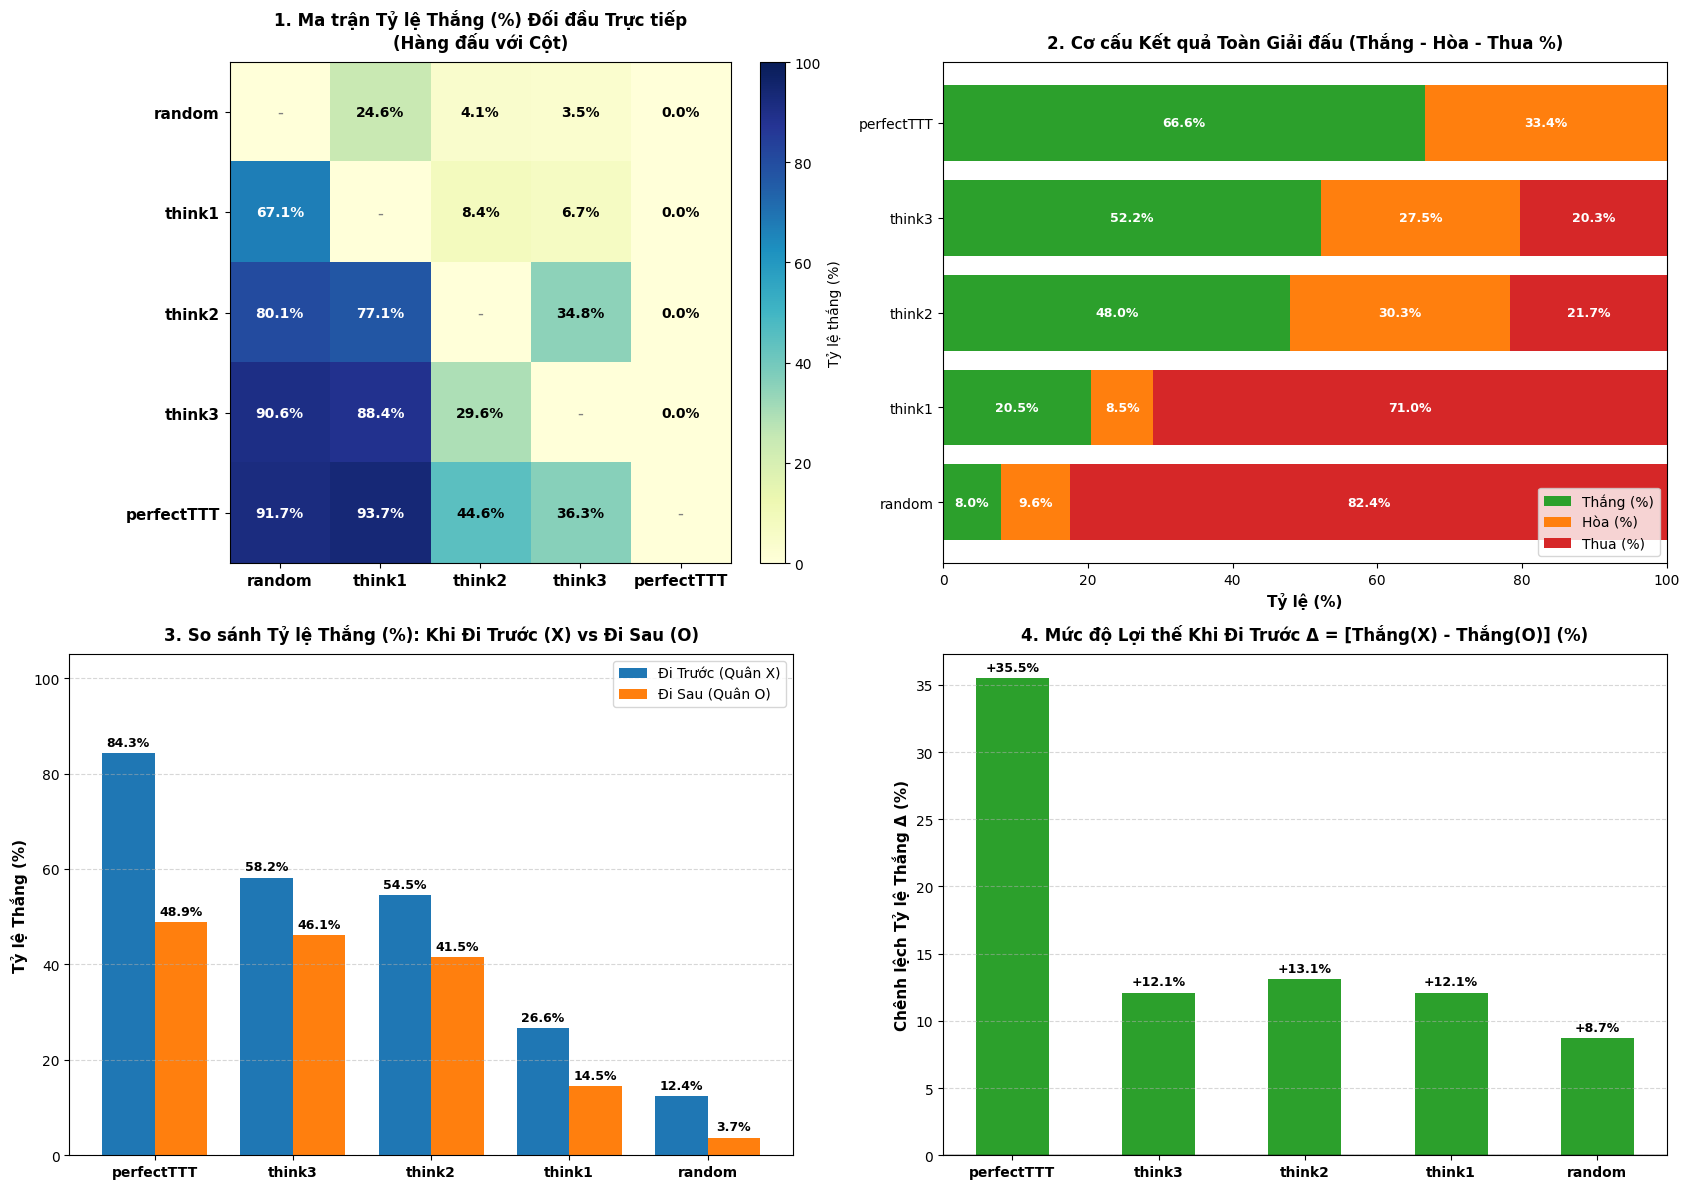

In [10]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# 1. THIẾT LẬP GIẢI ĐẤU VÒNG TRÒN (ROUND-ROBIN) VỚI THEO DÕI RIÊNG X VÀ O
# =============================================================================
perfectTTT = ttt_newell_simon

models = {
    "random": ttt_random,
    "think1": ttt_think1,
    "think2": ttt_think2,
    "think3": ttt_think3,
    "perfectTTT": perfectTTT
}

model_names = list(models.keys())
n_models = len(model_names)

# Khởi tạo các ma trận lưu kết quả toàn giải đấu
win_matrix = pd.DataFrame(0, index=model_names, columns=model_names)
draw_matrix = pd.DataFrame(0, index=model_names, columns=model_names)
loss_matrix = pd.DataFrame(0, index=model_names, columns=model_names)
winrate_matrix = pd.DataFrame(0.0, index=model_names, columns=model_names)

# [MỚI] Khởi tạo cấu trúc theo dõi thành tích riêng biệt khi đi trước (X) và đi sau (O)
stats_X = {m: {"win": 0, "draw": 0, "loss": 0} for m in model_names}
stats_O = {m: {"win": 0, "draw": 0, "loss": 0} for m in model_names}

print("=" * 75)
print("🚀 BẮT ĐẦU GIẢI ĐẤU VÒNG TRÒN GIỮA 5 MÔ HÌNH (TỔNG CỘNG 10.000 VÁN)...\n")

start_time = time.time()
match_count = 0
total_matches = (n_models * (n_models - 1)) // 2

for i in range(n_models):
    for j in range(i + 1, n_models):
        name_A = model_names[i]
        name_B = model_names[j]
        player_A = models[name_A]
        player_B = models[name_B]
        match_count += 1
        
        t0 = time.time()
        print(f"[{match_count:2d}/{total_matches}] Đang đấu: {name_A:10s} vs {name_B:10s} (1000 ván)...", end=" ")
        
        wins_A = 0
        wins_B = 0
        draws = 0
        
        # 500 ván: A đi trước (quân X), B đi sau (quân O)
        for _ in range(500):
            res = one_ttt_game(player_A, player_B)
            if res == 1:
                wins_A += 1
                stats_X[name_A]["win"] += 1
                stats_O[name_B]["loss"] += 1
            elif res == -1:
                wins_B += 1
                stats_X[name_A]["loss"] += 1
                stats_O[name_B]["win"] += 1
            else:
                draws += 1
                stats_X[name_A]["draw"] += 1
                stats_O[name_B]["draw"] += 1
                
        # 500 ván: B đi trước (quân X), A đi sau (quân O)
        for _ in range(500):
            res = one_ttt_game(player_B, player_A)
            if res == 1:
                wins_B += 1
                stats_X[name_B]["win"] += 1
                stats_O[name_A]["loss"] += 1
            elif res == -1:
                wins_A += 1
                stats_X[name_B]["loss"] += 1
                stats_O[name_A]["win"] += 1
            else:
                draws += 1
                stats_X[name_B]["draw"] += 1
                stats_O[name_A]["draw"] += 1
                
        # Ghi nhận kết quả vào ma trận đối đầu
        win_matrix.loc[name_A, name_B] = wins_A
        loss_matrix.loc[name_A, name_B] = wins_B
        draw_matrix.loc[name_A, name_B] = draws
        winrate_matrix.loc[name_A, name_B] = (wins_A / 1000) * 100
        
        win_matrix.loc[name_B, name_A] = wins_B
        loss_matrix.loc[name_B, name_A] = wins_A
        draw_matrix.loc[name_B, name_A] = draws
        winrate_matrix.loc[name_B, name_A] = (wins_B / 1000) * 100
        
        dt = time.time() - t0
        print(f"Xong trong {dt:5.2f}s! ({name_A}: {wins_A}T - {draws}H - {wins_B}B)")

total_time = time.time() - start_time
print("\n" + "=" * 75)
print(f"✅ HOÀN TẤT TOÀN BỘ 10.000 VÁN ĐẤU TRONG {total_time:.2f} GIÂY!")
print("=" * 75)

# =============================================================================
# 2. BẢNG 1: BẢNG TỔNG SẮP XẾP HẠNG (LEADERBOARD)
# =============================================================================
total_wins = win_matrix.sum(axis=1)
total_draws = draw_matrix.sum(axis=1)
total_losses = loss_matrix.sum(axis=1)
total_games = (n_models - 1) * 1000

leaderboard = pd.DataFrame({
    "Mô hình": model_names,
    "Số trận": total_games,
    "Thắng": total_wins.values,
    "Hòa": total_draws.values,
    "Thua": total_losses.values,
    "Thắng (%)": (total_wins.values / total_games * 100).round(1),
    "Hòa (%)": (total_draws.values / total_games * 100).round(1),
    "Thua (%)": (total_losses.values / total_games * 100).round(1),
    "Bất bại (%)": ((total_wins.values + total_draws.values) / total_games * 100).round(1),
    "Điểm số": (total_wins.values * 3 + total_draws.values * 1)
}).sort_values(by="Điểm số", ascending=False).reset_index(drop=True)

print("\n📊 1. BẢNG TỔNG SẮP XẾP HẠNG (LEADERBOARD):")
print("(Quy tắc tính điểm: Thắng = 3 điểm, Hòa = 1 điểm, Thua = 0 điểm)")
display(leaderboard)

# =============================================================================
# 3. BẢNG 2: MA TRẬN ĐỐI ĐẦU TRỰC TIẾP (HEAD-TO-HEAD MATRIX)
# =============================================================================
h2h_display = pd.DataFrame(index=model_names, columns=model_names)
for r in model_names:
    for c in model_names:
        if r == c:
            h2h_display.loc[r, c] = "-"
        else:
            w = win_matrix.loc[r, c]
            d = draw_matrix.loc[r, c]
            l = loss_matrix.loc[r, c]
            h2h_display.loc[r, c] = f"{w}T - {d}H - {l}B ({w/10:.1f}%)"

print("\n⚔️ 2. MA TRẬN ĐỐI ĐẦU TRỰC TIẾP (Hàng gặp Cột: Thắng - Hòa - Thua và % Thắng của Hàng):")
display(h2h_display)

# =============================================================================
# 4. BẢNG 3: SO SÁNH HIỆU QUẢ KHI ĐI TRƯỚC (QUÂN X) VÀ ĐI SAU (QUÂN O)
# =============================================================================
games_each_side = (n_models - 1) * 500  # 4 đối thủ x 500 = 2000 ván

xo_summary = pd.DataFrame({
    "Mô hình": model_names,
    "Trận (X)": games_each_side,
    "Thắng (X)": [stats_X[m]["win"] for m in model_names],
    "Hòa (X)": [stats_X[m]["draw"] for m in model_names],
    "Thua (X)": [stats_X[m]["loss"] for m in model_names],
    "Thắng X (%)": [round(stats_X[m]["win"] / (games_each_side / 100), 1) for m in model_names],
    "Bất bại X (%)": [round((stats_X[m]["win"] + stats_X[m]["draw"]) / (games_each_side / 100), 1) for m in model_names],
    "Trận (O)": games_each_side,
    "Thắng (O)": [stats_O[m]["win"] for m in model_names],
    "Hòa (O)": [stats_O[m]["draw"] for m in model_names],
    "Thua (O)": [stats_O[m]["loss"] for m in model_names],
    "Thắng O (%)": [round(stats_O[m]["win"] / (games_each_side / 100), 1) for m in model_names],
    "Bất bại O (%)": [round((stats_O[m]["win"] + stats_O[m]["draw"]) / (games_each_side / 100), 1) for m in model_names],
    "Lợi thế Đi Trước Δ (%)": [round((stats_X[m]["win"] - stats_O[m]["win"]) / (games_each_side / 100), 1) for m in model_names]
}).sort_values(by="Thắng X (%)", ascending=False).reset_index(drop=True)

print("\n🎯 3. BẢNG THỐNG KÊ CHI TIẾT KHI ĐI TRƯỚC (QUÂN X) VS ĐI SAU (QUÂN O):")
print("(Mỗi mô hình thi đấu 2000 ván cầm X và 2000 ván cầm O)")
display(xo_summary)

# =============================================================================
# 5. TRỰC QUAN HÓA BẰNG BỘ 4 BIỂU ĐỒ DASHBOARD
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(17, 12))

# Subplot [0, 0]: Heatmap % Thắng đối đầu
ax1 = axes[0, 0]
im = ax1.imshow(winrate_matrix.values, cmap="YlGnBu", vmin=0, vmax=100)
ax1.set_xticks(range(n_models))
ax1.set_yticks(range(n_models))
ax1.set_xticklabels(model_names, fontsize=11, fontweight="bold")
ax1.set_yticklabels(model_names, fontsize=11, fontweight="bold")
ax1.set_title("1. Ma trận Tỷ lệ Thắng (%) Đối đầu Trực tiếp\n(Hàng đấu với Cột)", fontsize=12, fontweight="bold", pad=10)

for i in range(n_models):
    for j in range(n_models):
        if i == j:
            ax1.text(j, i, "-", ha="center", va="center", color="gray", fontsize=12)
        else:
            val = winrate_matrix.iloc[i, j]
            color = "white" if val > 60 else "black"
            ax1.text(j, i, f"{val:.1f}%", ha="center", va="center", color=color, fontweight="bold", fontsize=10)

cbar = fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label("Tỷ lệ thắng (%)", fontsize=10)

# Subplot [0, 1]: Stacked Bar Chart Thắng - Hòa - Thua toàn giải
ax2 = axes[0, 1]
sorted_lb = leaderboard.sort_values(by="Điểm số", ascending=True)
m_names = sorted_lb["Mô hình"]
w_pct = sorted_lb["Thắng (%)"]
d_pct = sorted_lb["Hòa (%)"]
l_pct = sorted_lb["Thua (%)"]

ax2.barh(m_names, w_pct, color="#2ca02c", label="Thắng (%)")
ax2.barh(m_names, d_pct, left=w_pct, color="#ff7f0e", label="Hòa (%)")
ax2.barh(m_names, l_pct, left=w_pct + d_pct, color="#d62728", label="Thua (%)")
ax2.set_xlabel("Tỷ lệ (%)", fontsize=11, fontweight="bold")
ax2.set_title("2. Cơ cấu Kết quả Toàn Giải đấu (Thắng - Hòa - Thua %)", fontsize=12, fontweight="bold", pad=10)
ax2.set_xlim(0, 100)
ax2.legend(loc="lower right", fontsize=10)

for idx, (w, d, l) in enumerate(zip(w_pct, d_pct, l_pct)):
    if w > 7:
        ax2.text(w / 2, idx, f"{w:.1f}%", va="center", ha="center", color="white", fontweight="bold", fontsize=9)
    if d > 7:
        ax2.text(w + d / 2, idx, f"{d:.1f}%", va="center", ha="center", color="white", fontweight="bold", fontsize=9)
    if l > 7:
        ax2.text(w + d + l / 2, idx, f"{l:.1f}%", va="center", ha="center", color="white", fontweight="bold", fontsize=9)

# Subplot [1, 0]: Grouped Bar Chart So sánh Tỷ lệ Thắng khi đi X vs đi O
ax3 = axes[1, 0]
x_indices = np.arange(n_models)
bar_width = 0.38

sorted_xo = xo_summary.sort_values(by="Thắng X (%)", ascending=False)
win_x = sorted_xo["Thắng X (%)"].values
win_o = sorted_xo["Thắng O (%)"].values
labels = sorted_xo["Mô hình"].values

rects1 = ax3.bar(x_indices - bar_width/2, win_x, bar_width, label="Đi Trước (Quân X)", color="#1f77b4")
rects2 = ax3.bar(x_indices + bar_width/2, win_o, bar_width, label="Đi Sau (Quân O)", color="#ff7f0e")

ax3.set_ylabel("Tỷ lệ Thắng (%)", fontsize=11, fontweight="bold")
ax3.set_title("3. So sánh Tỷ lệ Thắng (%): Khi Đi Trước (X) vs Đi Sau (O)", fontsize=12, fontweight="bold", pad=10)
ax3.set_xticks(x_indices)
ax3.set_xticklabels(labels, fontsize=10, fontweight="bold")
ax3.set_ylim(0, 105)
ax3.legend(loc="upper right", fontsize=10)
ax3.grid(axis="y", linestyle="--", alpha=0.5)

for rect in rects1:
    h = rect.get_height()
    ax3.annotate(f"{h:.1f}%", xy=(rect.get_x() + rect.get_width()/2, h),
                 xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=9, fontweight="bold")
for rect in rects2:
    h = rect.get_height()
    ax3.annotate(f"{h:.1f}%", xy=(rect.get_x() + rect.get_width()/2, h),
                 xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Subplot [1, 1]: Lợi thế Đi trước Delta = Win(X) - Win(O)
ax4 = axes[1, 1]
delta_values = sorted_xo["Lợi thế Đi Trước Δ (%)"].values
colors = ["#2ca02c" if val >= 0 else "#d62728" for val in delta_values] # Xanh nếu X hơn O
bars_delta = ax4.bar(labels, delta_values, color=colors, width=0.5)
ax4.set_ylabel("Chênh lệch Tỷ lệ Thắng Δ (%)", fontsize=11, fontweight="bold")
ax4.set_title("4. Mức độ Lợi thế Khi Đi Trước Δ = [Thắng(X) - Thắng(O)] (%)", fontsize=12, fontweight="bold", pad=10)
ax4.grid(axis="y", linestyle="--", alpha=0.5)
ax4.set_xticklabels(labels, fontsize=10, fontweight="bold")
ax4.axhline(0, color="black", linewidth=1)

for rect, val in zip(bars_delta, delta_values):
    h = rect.get_height()
    pos = h if h >= 0 else 0
    ax4.annotate(f"+{val:.1f}%" if val >= 0 else f"{val:.1f}%",
                 xy=(rect.get_x() + rect.get_width()/2, pos),
                 xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()
